# Module 11 Challenge
## Deliverable 2: Scrape and Analyze Mars Weather Data

In [16]:
# Import relevant libraries
from splinter import Browser
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import time
import pandas as pd

In [18]:
browser = Browser('chrome')

### Step 1: Visit the Website

Use automated browsing to visit the [Mars Temperature Data Site](https://static.bc-edx.com/data/web/mars_facts/temperature.html). Inspect the page to identify which elements to scrape.

   > **Hint** To identify which elements to scrape, you might want to inspect the page by using Chrome DevTools to discover whether the table contains usable classes.


In [20]:
# Visit the website
url = "https://static.bc-edx.com/data/web/mars_facts/temperature.html"
browser.visit(url)

# Optional delay for loading the page 
time.sleep(2)

### Step 2: Scrape the Table

Create a Beautiful Soup object and use it to scrape the data in the HTML table.

Note that this can also be achieved by using the Pandas `read_html` function. However, use Beautiful Soup here to continue sharpening your web scraping skills.

In [22]:
# Create a Beautiful Soup Object
html = browser.html
weather_soup = BeautifulSoup(html, 'html.parser')

In [23]:
# Find the table
table = weather_soup.find('table', class_='table')

# Extract all rows of data
rows = table.find_all('tr')

### Step 3: Store the Data

Assemble the scraped data into a Pandas DataFrame. The columns should have the same headings as the table on the website. Here’s an explanation of the column headings:

* `id`: the identification number of a single transmission from the Curiosity rover
* `terrestrial_date`: the date on Earth
* `sol`: the number of elapsed sols (Martian days) since Curiosity landed on Mars
* `ls`: the solar longitude
* `month`: the Martian month
* `min_temp`: the minimum temperature, in Celsius, of a single Martian day (sol)
* `pressure`: The atmospheric pressure at Curiosity's location

In [25]:
# Create an empty list
mars_weather_data = []

# Loop through the scraped data to create a list of rows
for row in rows[1:]:
    # Extract all columns in the row
    columns = row.find_all('td')
    
    # Extract text from each column and store in a list
    row_data = [col.text.strip() for col in columns]
    
    # Append the row data to the mars_weather_data list
    mars_weather_data.append(row_data)

In [31]:
# Define the column names
columns = ['id', 'terrestrial_date', 'sol', 'ls', 'month', 'min_temp', 'pressure']

# Create a Pandas DataFrame by using the list of rows and a list of the column names
mars_weather_df = pd.DataFrame(mars_weather_data, columns=columns)

In [33]:
# Confirm DataFrame was created successfully
print(mars_weather_df.head())

   id terrestrial_date sol   ls month min_temp pressure
0   2       2012-08-16  10  155     6    -75.0    739.0
1  13       2012-08-17  11  156     6    -76.0    740.0
2  24       2012-08-18  12  156     6    -76.0    741.0
3  35       2012-08-19  13  157     6    -74.0    732.0
4  46       2012-08-20  14  157     6    -74.0    740.0


### Step 4: Prepare Data for Analysis

Examine the data types that are currently associated with each column. If necessary, cast (or convert) the data to the appropriate `datetime`, `int`, or `float` data types.

  > **Hint** You can use the Pandas `astype` and `to_datetime` methods to accomplish this task.


In [36]:
# Examine data type of each column
mars_weather_df = mars_weather_df.astype('object')

print(mars_weather_df.dtypes)

id                  object
terrestrial_date    object
sol                 object
ls                  object
month               object
min_temp            object
pressure            object
dtype: object


In [38]:
# Change data types for data analysis
mars_weather_df['terrestrial_date'] = pd.to_datetime(mars_weather_df['terrestrial_date'])  
mars_weather_df['sol'] = mars_weather_df['sol'].astype('int32') 
mars_weather_df['ls'] = mars_weather_df['ls'].astype('int32') 
mars_weather_df['month'] = mars_weather_df['month'].astype('int32') 
mars_weather_df['min_temp'] = mars_weather_df['min_temp'].astype('float64') 
mars_weather_df['pressure'] = mars_weather_df['pressure'].astype('float64')

In [40]:
# Confirm type changes were successful by examining data types again
print(mars_weather_df.dtypes)

id                          object
terrestrial_date    datetime64[ns]
sol                          int32
ls                           int32
month                        int32
min_temp                   float64
pressure                   float64
dtype: object


### Step 5: Analyze the Data

Analyze your dataset by using Pandas functions to answer the following questions:

1. How many months exist on Mars?
2. How many Martian (and not Earth) days worth of data exist in the scraped dataset?
3. What are the coldest and the warmest months on Mars (at the location of Curiosity)? To answer this question:
    * Find the average the minimum daily temperature for all of the months.
    * Plot the results as a bar chart.
4. Which months have the lowest and the highest atmospheric pressure on Mars? To answer this question:
    * Find the average the daily atmospheric pressure of all the months.
    * Plot the results as a bar chart.
5. About how many terrestrial (Earth) days exist in a Martian year? To answer this question:
    * Consider how many days elapse on Earth in the time that Mars circles the Sun once.
    * Visually estimate the result by plotting the daily minimum temperature.


In [43]:
# 1. How many months are there on Mars?
num_months = mars_weather_df['month'].nunique()
print(num_months)

12


In [45]:
# 2. How many sols (Martian days) worth of data are there?
num_sols = mars_weather_df['sol'].nunique()
print(num_sols)

1867


In [47]:
# 3. What is the average minimum temperature by month?
avg_min_temp = mars_weather_df.groupby('month')['min_temp'].mean()
print(avg_min_temp)

month
1    -77.160920
2    -79.932584
3    -83.307292
4    -82.747423
5    -79.308725
6    -75.299320
7    -72.281690
8    -68.382979
9    -69.171642
10   -71.982143
11   -71.985507
12   -74.451807
Name: min_temp, dtype: float64


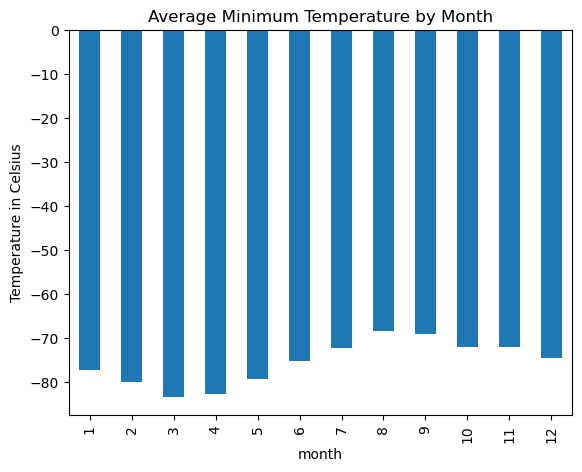

In [49]:
# Plot the average minimum temperature by month
avg_min_temp.plot(kind='bar', figsize=(6.5, 5))
plt.title('Average Minimum Temperature by Month')
plt.xlabel('month')
plt.ylabel('Temperature in Celsius')
plt.show()

month
3    -83.307292
4    -82.747423
2    -79.932584
5    -79.308725
1    -77.160920
6    -75.299320
12   -74.451807
7    -72.281690
11   -71.985507
10   -71.982143
9    -69.171642
8    -68.382979
Name: min_temp, dtype: float64


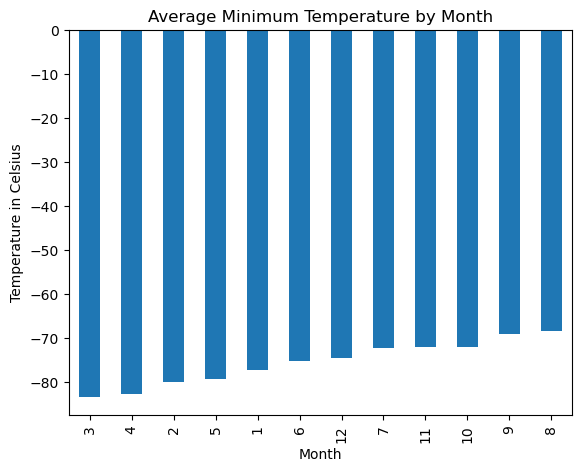

In [63]:
# Identify the coldest and hottest months in Curiosity's location by sorting the previous graph
# Sort the data by average minimum temperature
sorted_avg_min_temp = avg_min_temp.sort_values()

# Print sorted data for reference
print(sorted_avg_min_temp)

# Plot the sorted bar chart
sorted_avg_min_temp.plot(kind='bar', figsize=(6.5, 5))
plt.title('Average Minimum Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Temperature in Celsius')
plt.show()

In [81]:
# 4. What is the average pressure by month?
avg_pressure = mars_weather_df.groupby('month')['pressure'].mean()
print(avg_pressure)


month
1     862.488506
2     889.455056
3     877.322917
4     806.329897
5     748.557047
6     745.054422
7     795.105634
8     873.829787
9     913.305970
10    887.312500
11    857.014493
12    842.156627
Name: pressure, dtype: float64


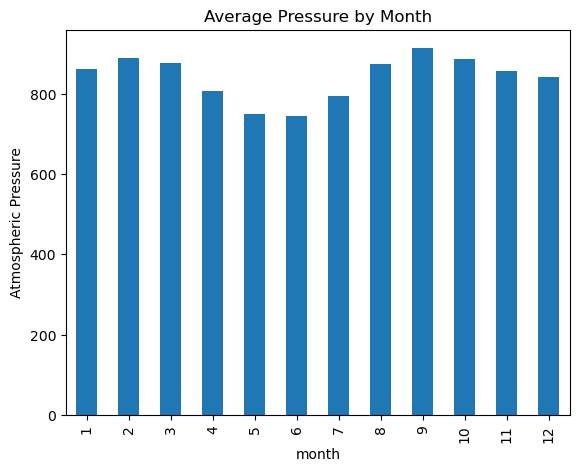

In [83]:
# Plot the average pressure by month
avg_pressure.plot(kind='bar', figsize=(6.5, 5))
plt.title('Average Pressure by Month')
plt.xlabel('month')
plt.ylabel('Atmospheric Pressure')
plt.show()


The month with the lowest pressure is: 6
The month with the highest pressure is: 9


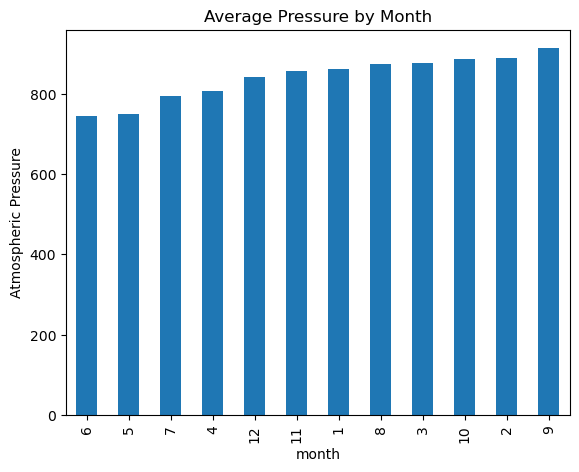

In [89]:
# Identify the lowest and highest pressure months in Curiosity's location by sorting the previous graph
lowest_avg_pressure = avg_pressure.idxmin()
highest_avg_pressure = avg_pressure.idxmax()

print(f"The month with the lowest pressure is: {lowest_avg_pressure}")
print(f"The month with the highest pressure is: {highest_avg_pressure}")

# Sort the average pressure by value
sorted_avg_pressure = avg_pressure.sort_values()

sorted_avg_pressure.plot(kind='bar', figsize=(6.5, 5))
plt.title('Average Pressure by Month')
plt.xlabel('month')
plt.ylabel('Atmospheric Pressure')
plt.show()

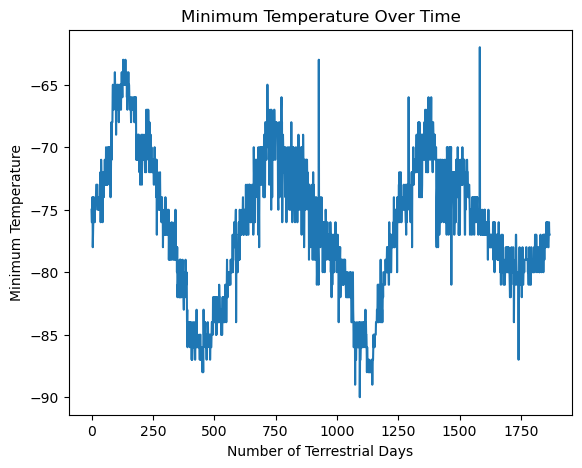

In [91]:
# 5. How many terrestrial (Earth) days are there in a Martian year?
# Visually estimate the result by plotting the daily minimum temperature of each observation in the data set.
plt.figure(figsize=(6.5, 5))
plt.plot(mars_weather_df.index, mars_weather_df['min_temp'])
plt.title('Minimum Temperature Over Time')
plt.xlabel('Number of Terrestrial Days')
plt.ylabel('Minimum Temperature')
plt.show()

Minimum Temperature

The coldest months on Mars occur during month 3 and 4, with an average minimum temperature of -83 C. This aligns with the southern hemisphere’s winter. In contrast, the warmest months occurs during month 8 and 9 which aligns with the southern hemisphere’s summer. These extreme temperature variations highlight the need for mission equipment to withstand Martian environment. Mars exhibit distinct seasonal patterns that is related to the axial tilt and elliptical orbit. Colder months correlate with higher pressure, while warmer months have lower pressure.

Atmospheric Pressure

The atmospheric pressure data highlights Mars’ extreme seasonal fluctuations, crucial for understanding the atmosphere’s behavior. This is especially important for lander and rover missions that depend on atmospheric conditions during descent and operations. The lowest pressures occur in Month 6 because the atmosphere is less dense during the Martian summer. Whereas, the highest pressure is observed in Month 9, most likely due to the winter season, where cooler temperatures cause atmospheric contraction and increased pressure. These pressure trends reflect Mars’ elliptical orbit, leading to greater atmospheric variations compared to Earth. Taken this into consideration, rovers and landers should account for these fluctuations, especially the pressure is low during the summer.

Year Length

The chart demonstrates two complete cycles of minimum temperature fluctuations, representing two Martian years. Each cycle begins starts with gradual cooling, reaches a low point, and then warms back up, reflecting Mars' axial tilt and elliptical orbit. The clear periodicity in the chart confirms the estimated length of the Martian year and provides critical insights into seasonal temperature trends. This information is vital for both robotic and potential human exploration, emphasizing the importance of timing missions to optimize conditions.

### Step 6: Save the Data

Export the DataFrame to a CSV file.

In [108]:
#Write the data to a CSV
mars_weather_df.to_csv('mars_weather_data.csv', index=False)

print("Data has been successfully written to 'mars_weather_data.csv'.")

Data has been successfully written to 'mars_weather_data.csv'.


In [110]:
browser.quit()